In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import curve_fit
import natural_cubic_spline_stack_overflow as ncs # taken from stack overflow
import csv

In [2]:
# Extracting data from the source file into a panda Dataframe
file = "pop_data.xlsx"
# This file should be placed in the same directory as this notebook (on the JupyterHub server)

# We read the data and store it in a Dataframe called "data", using the read_excel() panda function
data = pd.read_excel(file, index_col = None, header = 0, usecols = 'A:H')

In [3]:
print(data)

     TIME  JAN POPULATION  JUL POPULATION  OCT POPULATION  APR POPULATION  \
0    2100             NaN             NaN             NaN             NaN   
1    2099             NaN             NaN             NaN             NaN   
2    2098             NaN             NaN             NaN             NaN   
3    2097             NaN             NaN             NaN             NaN   
4    2096             NaN             NaN             NaN             NaN   
..    ...             ...             ...             ...             ...   
496  1604             NaN             NaN             NaN             NaN   
497  1603             NaN             NaN             NaN             NaN   
498  1602             NaN             NaN             NaN             NaN   
499  1601             NaN             NaN             NaN             NaN   
500  1600             NaN             NaN             NaN             NaN   

     1900s POPULATION  HYDE DATA     UN pred  
0                 NaN       

In [4]:
# collected the data in a single list to be able to plot it and use it for regression
data_col = pd.read_excel('pop_collection.xlsx', index_col = None, header = 0, usecols = 'A:B')
print(data_col)

     POPULATION  YEAR
0    33127478.5  2100
1    33302992.0  2099
2    33475731.5  2098
3    33645991.5  2097
4    33811182.5  2096
..          ...   ...
172   9536161.0  1730
173   9278427.0  1720
174   9027659.0  1710
175   8000000.0  1700
176   8500000.0  1600

[177 rows x 2 columns]


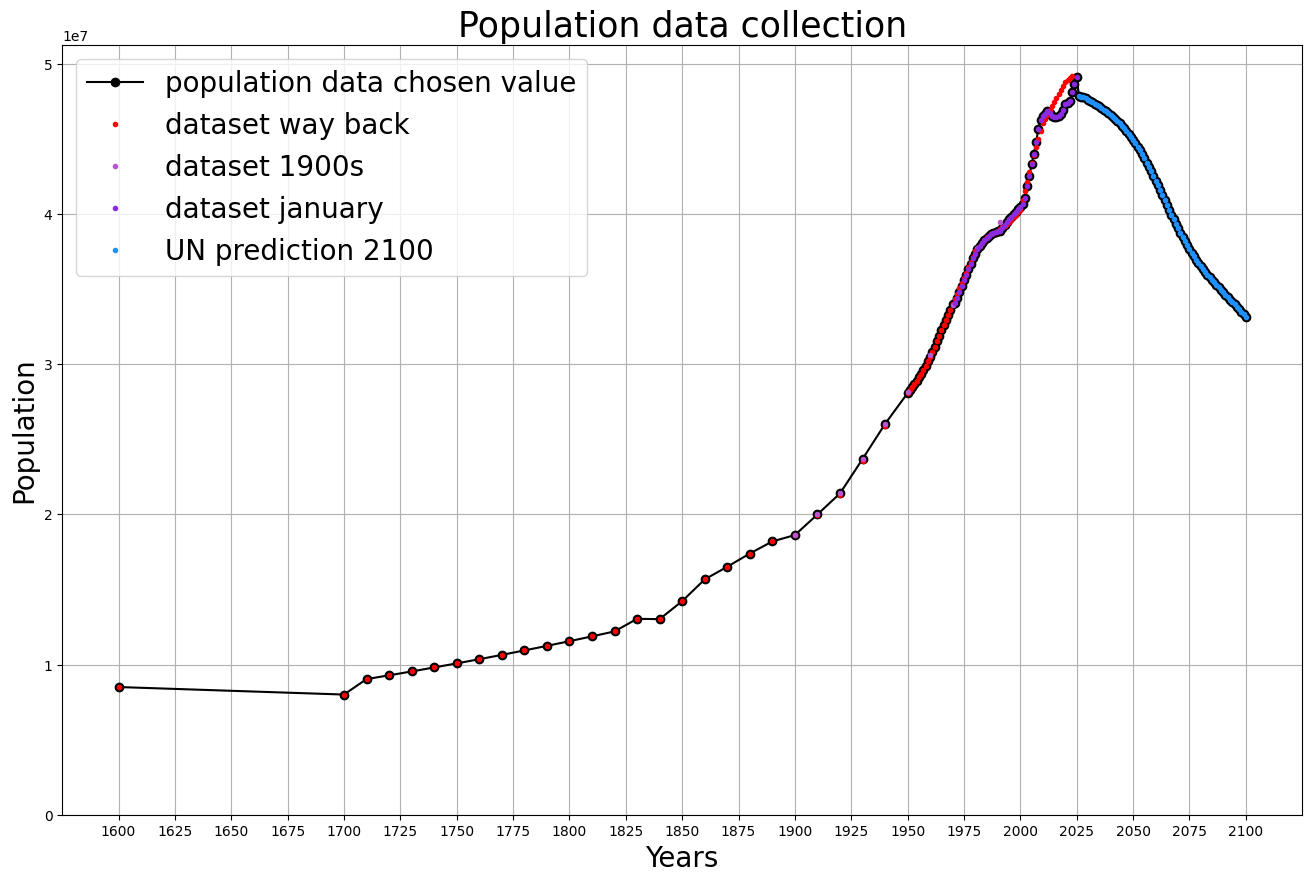

In [5]:
plt.figure(figsize=(16,10))
plt.plot(data_col['YEAR'], data_col['POPULATION'], 'o-', color = 'black', label = f'population data chosen value')
plt.plot(data["TIME"], data["HYDE DATA"], '.', label="dataset way back", color='red')
plt.plot(data["TIME"], data["1900s POPULATION"], '.', label="dataset 1900s", color = 'mediumorchid')
plt.plot(data["TIME"], data["JAN POPULATION"], '.', label="dataset january", color = 'blueviolet')
plt.plot(data["TIME"], data["UN pred"], '.', label="UN prediction 2100", color = 'dodgerblue')
plt.grid()
plt.legend(loc = 'best', fontsize = 20)
plt.xticks(list(range(1600, 2101, 25)))
plt.xlabel('Years', fontsize = 20)
plt.ylabel('Population', fontsize = 20)
plt.title('Population data collection', fontsize = 25)
plt.ylim(ymin=0)
plt.show()


In [6]:
def logistic(x:np.ndarray,ti:float,tau:float,C0:float,C1:float) -> np.ndarray:
    """
    General logistic function.
    Arguments:
    - x: np.ndarray of observation points (time)
    - ti: inflection time
    - tau: transition time coefficient
    - C0: start value
    - C1: end value

    Returns:
    - np.ndarray with len(x) number of points
    """
    return (C1 - C0)/(1 + np.exp(-(x - ti) / tau)) + C0 

The optimal choice of parameters for the logistic function, given the sample data, is [1.94983823e+03 1.70146544e+01 1.24676937e+07 4.21694855e+07] (ti, tau, C0, C1).


<Figure size 1600x1000 with 0 Axes>

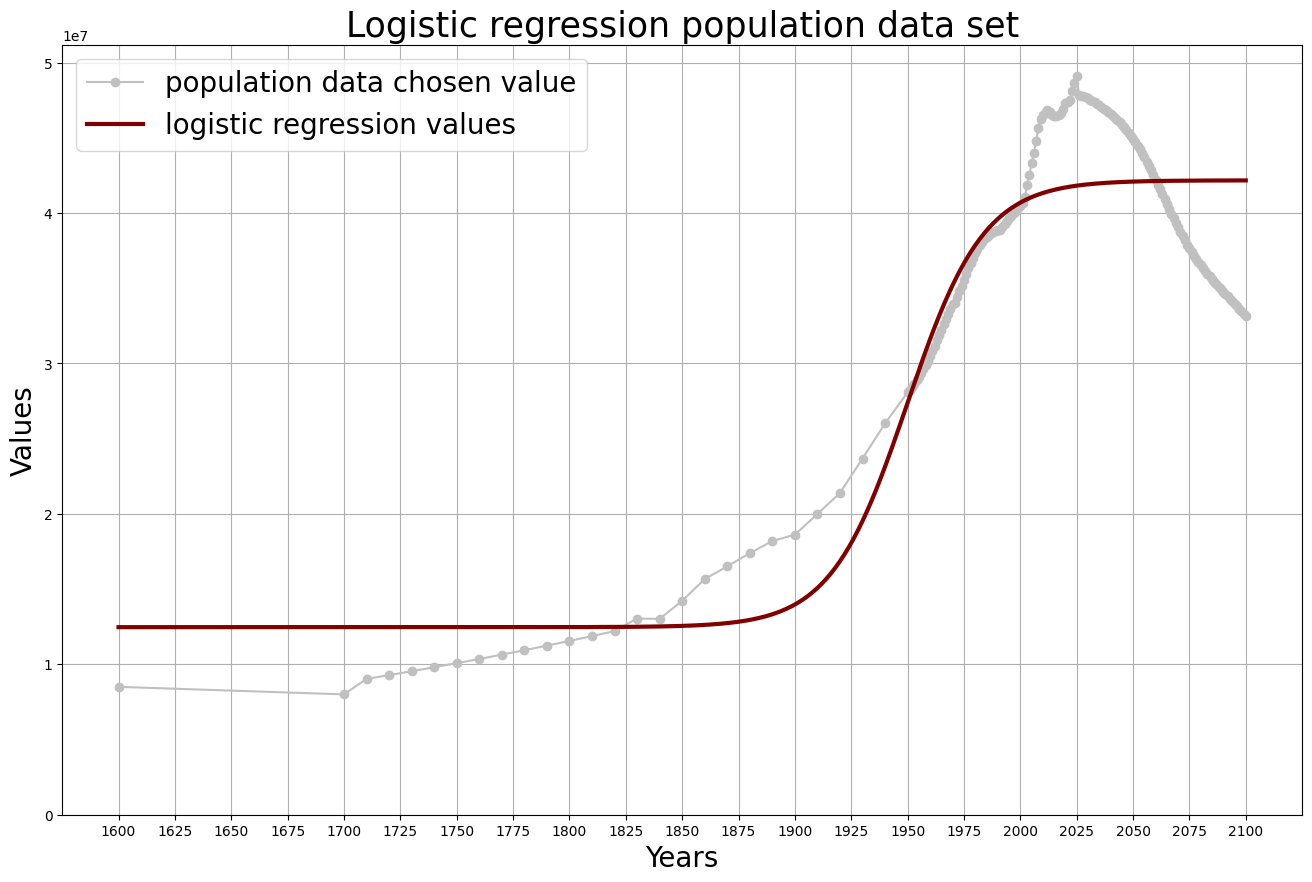

In [7]:
# Logistic regression using method from warmup 15

plt.figure(figsize=(16,10))
#add plot and labels here
all_years = range(1600, 2101, 1)
inputs = data_col['YEAR']
outputs = data_col['POPULATION']
pred_inputs = all_years
# it might be necessary to adjust the bounds argument, 
# determining the extreme acceptable value for the parameters of the logistic function.
# Bounds are set as ([low_ti, low_tau, low_Co, low_C1],[high_ti,high_tau, high_Co, high_C1 ])
popt, pcov = curve_fit(logistic, inputs, outputs, bounds = ([min(inputs), 0, 0, 0], [max(inputs), 10*8, 10**8, 10**8]))
pred_outputs = logistic(pred_inputs, *popt)

print(f'The optimal choice of parameters for the logistic function, given the sample data, is {popt} (ti, tau, C0, C1).')
plt.figure(figsize=(16,10))
plt.plot(data_col['YEAR'], data_col['POPULATION'], 'o-', color = 'silver', label = f'population data chosen value')
plt.plot(pred_inputs, pred_outputs, color = 'maroon', lw = 3, label = 'logistic regression values')
plt.legend(loc = 'best', fontsize = 20)
plt.xticks(list(range(1600, 2101, 25)))
plt.xlabel('Years', fontsize = 20)
plt.ylabel('Values', fontsize = 20)
plt.title('Logistic regression population data set', fontsize = 25)
plt.ylim(ymin=0)
plt.grid()
plt.show()

pred_inputs_log_p = pred_inputs
pred_outputs_log_p = pred_outputs

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


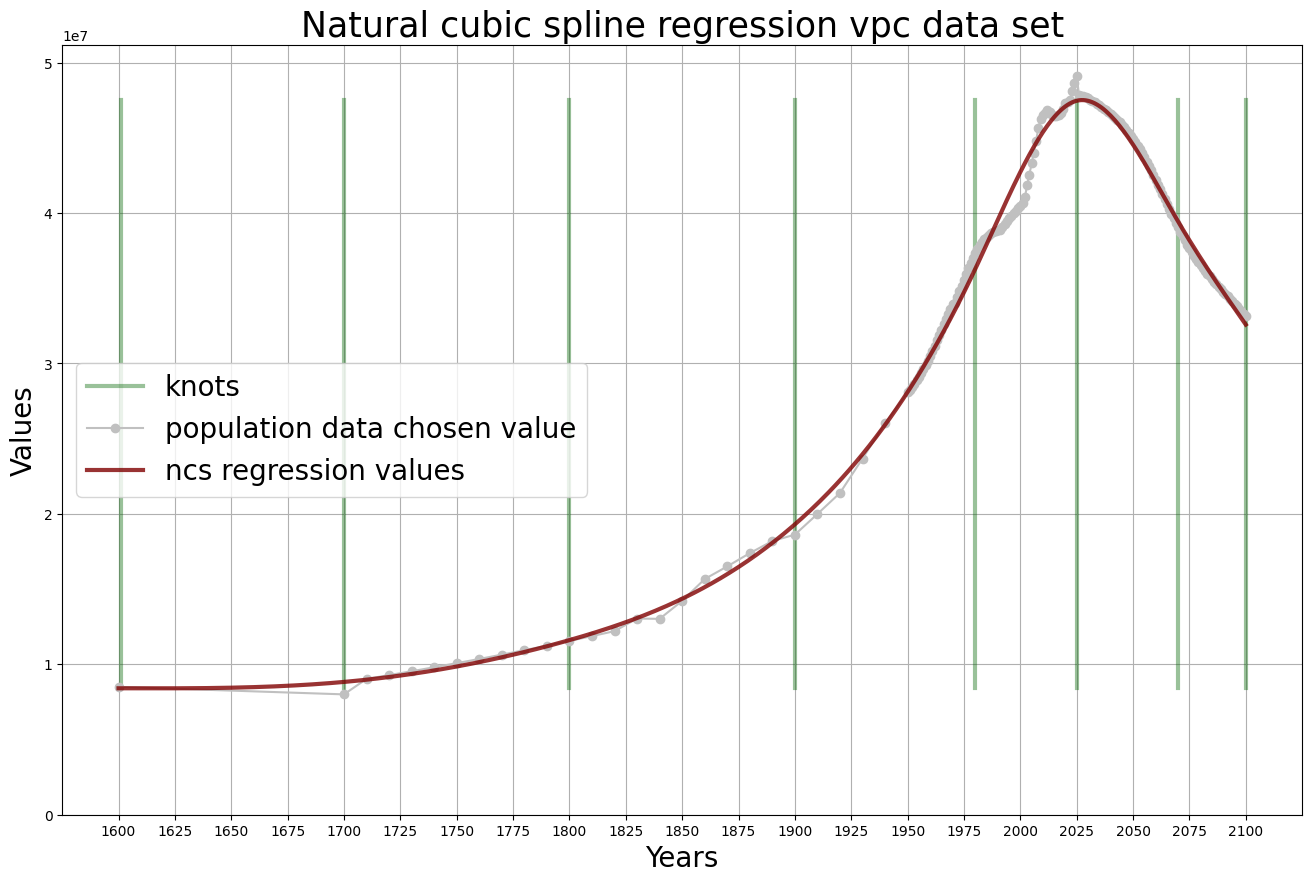

In [8]:
# natural cubic spline seems a better fit to account for population decline in the future
inputs = data_col['YEAR']
outputs = data_col['POPULATION']
pred_inputs = np.array(all_years)

# i choose the knots manually
knots = [1601, 1700, 1800, 1900, 1980, 2025, 2070, 2100]

# setting up the actual model (training)
ncs_model = ncs.get_natural_cubic_spline_model(inputs, outputs, knots = knots)

# predicting of the single curve by the model
pred_outputs = ncs_model.predict(pred_inputs)

#plot the knots:
plt.figure(figsize=(16,10))
i=1
for knot in knots:
    if i == 1:
        plt.plot([knot, knot], [min(pred_outputs), max(pred_outputs)], lw = 3, color = 'darkgreen', label = 'knots', alpha = 0.4)
        i +=1
    else:
        plt.plot([knot, knot], [min(pred_outputs), max(pred_outputs)], lw = 3, color = 'darkgreen', alpha = 0.4)

plt.plot(data_col['YEAR'], data_col['POPULATION'], 'o-', color = 'silver', label = f'population data chosen value')
plt.plot(pred_inputs, pred_outputs, color = 'maroon', lw = 3, alpha = 0.8, label = 'ncs regression values')
plt.legend(loc = 'best', fontsize = 20)
plt.xticks(list(range(1600, 2101, 25)))
plt.grid()
plt.xlabel('Years', fontsize = 20)
plt.ylabel('Values', fontsize = 20)
plt.title('Natural cubic spline regression vpc data set', fontsize = 25)
plt.ylim(ymin=0)
plt.show()


pred_inputs_ncs_p = pred_inputs
pred_outputs_ncs_p = pred_outputs

In [9]:
# making the data ready to export to csv by making an array and transposing it
exportdata = np.array([pred_inputs, pred_outputs])
exportdata = exportdata.T
print(exportdata.shape)

(501, 2)


In [10]:
# exporting to csv. finished :)
filename = 'population.csv'

# Open the file in write mode ('w') and use writerows()
with open(filename, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(exportdata)

print(f"Data successfully exported to {filename} using csv module.")


Data successfully exported to population.csv using csv module.
